In [1]:
import qubx

%qubxd

%load_ext autoreload
%autoreload 2

from typing import cast
import numpy as np
import pandas as pd
import asyncio
from pathlib import Path
from qubx.core.lookups import lookup
from qubx.connectors.ccxt.factory import get_ccxt_exchange
from qubx import logger, QubxLogConfig
from qubx.core.interfaces import IStrategy, IStrategyContext, BaseErrorEvent, IStrategyInitializer
from qubx.utils.runner.runner import (
    run_strategy,
    StrategyConfig,
    AccountConfigurationManager,
    ExchangeConfig,
    LoggingConfig,
)
from qubx.utils.runner.configs import LiveConfig, StorageConfig
from qubx.core.basics import DataType, MarketEvent
from qubx.utils.charting.lookinglass import LookingGlass

QubxLogConfig.set_log_level("DEBUG")


⠀⠀⡰⡖⠒⠒⢒⢦⠀⠀   
⠀⢠⠃⠈⢆⣀⣎⣀⣱⡀  QUBX | Quantitative Backtesting Environment 
⠀⢳⠒⠒⡞⠚⡄⠀⡰⠁         (c) 2025, ver. 1.0.0.dev3
⠀⠀⠱⣜⣀⣀⣈⣦⠃⠀⠀⠀ 
        


2026-03-06 09:39:07.419 [ 🐞 ] (misc) uvloop installed successfully
2026-03-06 09:39:07.421 [ 🐞 ] (runner) Shared event loop started in background thread
2026-03-06 09:39:07.421 [ 🐞 ] (ntp) NTP offset controller thread is started


## 1.0 Define simple strategy that does nothing

Just subscribes to OHLC[1h], orderbook aggregated in 0.01% buckets top 100 levels (1% depth).

In [2]:
class TestStrategy(IStrategy):
    def on_init(self, initializer: IStrategyInitializer):
        initializer.set_base_subscription(DataType.OHLC["1h"])
        initializer.set_subscription_warmup({DataType.OHLC["1h"]: "1d"})

    def on_market_data(self, ctx: IStrategyContext, data: MarketEvent):
        pass

    def on_error(self, ctx: IStrategyContext, error: BaseErrorEvent) -> None:
        logger.error(f"Error: {error}")

    def on_stop(self, ctx: IStrategyContext):
        logger.info("Stopping test strategy")

## 2.0 Run strategy without blocking

In [ ]:
ctx = run_strategy(
    config=StrategyConfig(
        name="TestStrategy",
        strategy=TestStrategy,
        aux=StorageConfig(storage="ccxt", args={"max_history": "10d"}),
        live=LiveConfig(
            exchanges={
                "BINANCE.UM": ExchangeConfig(
                    connector="ccxt",
                    universe=["BTCUSDT", "ETHUSDT"],
                )
            },
            logging=LoggingConfig(
                logger="InMemoryLogsWriter",
                position_interval="10s",
                portfolio_interval="1m",
                heartbeat_interval="10m",
            ),
        ),
    ),
    account_manager=AccountConfigurationManager(),
    paper=True,
    blocking=False,
)

2026-03-06 08:39:07.450 [🐞] (runner) Setup InMemoryLogsWriter logger...
2026-03-06 08:39:08.023 [🐞] (exchange_manager) ExchangeManager: Started stale data detection monitoring for BINANCE.UM
2026-03-06 08:39:08.024 [🐞] (exchange_manager) Registered recreation callback for BINANCE.UM
2026-03-06 08:39:08.024 [ℹ️] (data) BINANCE.UM Initialized
2026-03-06 08:39:08.025 [ℹ️] (runner) - Strategy: TestStrategy
- Mode: paper
- Parameters: {}
2026-03-06 08:39:08.035 [ℹ️] (warmup_service) BINANCE.UM Starting subscription warmup for 2 items
2026-03-06 08:39:08.757 [🐞] (ohlc) BINANCE.UM BINANCE.UM:SWAP:ETHUSDT: loaded 24 1h bars
2026-03-06 08:39:09.056 [🐞] (ohlc) BINANCE.UM BINANCE.UM:SWAP:BTCUSDT: loaded 24 1h bars
2026-03-06 08:39:09.057 [ℹ️] (warmup_service) BINANCE.UM Warmup completed successfully
2026-03-06 08:39:09.059 [ℹ️] (context) [StrategyContext] :: Start processing market data
2026-03-06 08:39:09.060 [ℹ️] (processing) Waiting for all instruments (0/2 ready). Missing: ['ETHUSDT', 'BTCUSD

2026-03-06 08:39:09.449 [ℹ️] (loggers) Heartbeat at 2026-03-06T08:30:00
2026-03-06 08:39:10.643 [ℹ️] (processing) All 2 instruments have data - strategy ready to start
2026-03-06 08:39:10.644 [🐞] (processing) [ProcessingManager] :: Invoking TestStrategy on_warmup_finished
2026-03-06 08:39:10.645 [🐞] (processing) [ProcessingManager] :: TestStrategy warmup finished completed
2026-03-06 08:39:10.744 [🐞] (processing) [ProcessingManager] :: Invoking TestStrategy on_fit
2026-03-06 08:39:10.745 [🐞] (processing) [ProcessingManager] :: TestStrategy is fitted
2026-03-06 08:39:13.029 [ℹ️] (warmup_service) BINANCE.UM Starting subscription warmup for 5 items
2026-03-06 08:39:13.318 [🐞] (ohlc) BINANCE.UM BINANCE.UM:SWAP:XRPUSDT: loaded 24 1h bars
2026-03-06 08:39:13.607 [🐞] (ohlc) BINANCE.UM BINANCE.UM:SWAP:DOGEUSDT: loaded 24 1h bars
2026-03-06 08:39:13.895 [🐞] (ohlc) BINANCE.UM BINANCE.UM:SWAP:ADAUSDT: loaded 24 1h bars
2026-03-06 08:39:14.184 [🐞] (ohlc) BINANCE.UM BINANCE.UM:SWAP:LINKUSDT: loaded

In [4]:
add_symbols = ["BTCUSDT", "ETHUSDT", "XRPUSDT", "SOLUSDT", "DOGEUSDT", "ADAUSDT", "LINKUSDT"]
add_instruments = [ctx.query_instrument(symbol) for symbol in add_symbols]
print(add_instruments)
ctx.set_universe(add_instruments)

[BINANCE.UM:SWAP:BTCUSDT, BINANCE.UM:SWAP:ETHUSDT, BINANCE.UM:SWAP:XRPUSDT, BINANCE.UM:SWAP:SOLUSDT, BINANCE.UM:SWAP:DOGEUSDT, BINANCE.UM:SWAP:ADAUSDT, BINANCE.UM:SWAP:LINKUSDT]


In [5]:
ctx.subscribe(DataType.ORDERBOOK[0.01, 100])

Plot hourly price over the last day

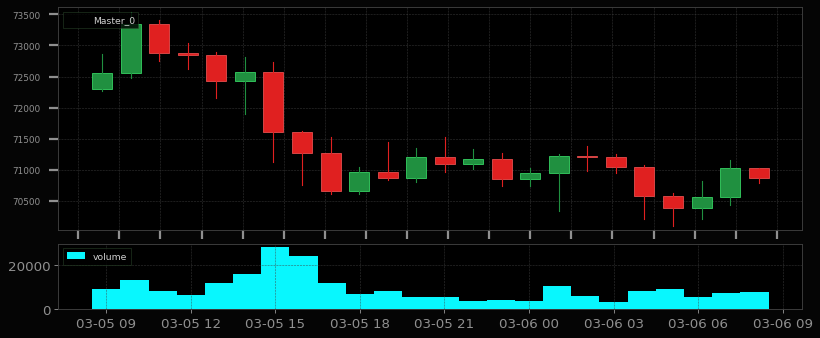

In [6]:
ohlc = ctx.ohlc(ctx.query_instrument("BTCUSDT")).pd()

LookingGlass(
    ohlc,
    {
        "volume": ["bars", ohlc["volume"]],
    },
    backend="mpl",
).look()

## 3.0 Plot the orderbook

In [7]:
symbol = "BTCUSDT"
instrument = ctx.query_instrument(symbol)
ob = ctx.get_cached_market_data(instrument, DataType.ORDERBOOK)
ob.pd()

,top_bid,top_ask,tick_size,bids,asks
time,,,,,
2026-03-06 08:39:40.603,70864.9,70865.0,7.0,"[5.451999999999998, 7.344999999999997, 10.9229...","[1.4119999999999988, 6.547999999999999, 10.286..."
2026-03-06 08:39:40.705,70864.9,70865.0,7.0,"[5.490999999999998, 7.585999999999997, 10.9229...","[1.4139999999999988, 6.547999999999999, 10.286..."
2026-03-06 08:39:40.809,70864.9,70865.0,7.0,"[5.492999999999998, 7.537999999999997, 10.4149...","[1.474999999999999, 6.52, 10.927999999999999, ..."
2026-03-06 08:39:40.913,70864.9,70865.0,7.0,"[5.484999999999998, 7.538999999999996, 10.4149...","[1.474999999999999, 6.526, 10.927999999999999,..."
2026-03-06 08:39:41.015,70864.9,70865.0,7.0,"[5.462999999999998, 7.292999999999996, 10.4149...","[1.480999999999999, 6.549999999999999, 11.232,..."
...,...,...,...,...,...
2026-03-06 08:40:08.509,70943.5,70943.6,7.0,"[14.869000000000003, 5.119999999999997, 15.679...","[4.114999999999997, 14.206999999999997, 11.397..."
2026-03-06 08:40:08.611,70943.5,70943.6,7.0,"[15.653000000000004, 5.116999999999997, 15.648...","[2.621999999999998, 14.193, 10.329999999999997..."
2026-03-06 08:40:08.713,70943.5,70943.6,7.0,"[15.194, 5.086999999999997, 15.654000000000002...","[2.482999999999998, 14.208, 10.329999999999997..."


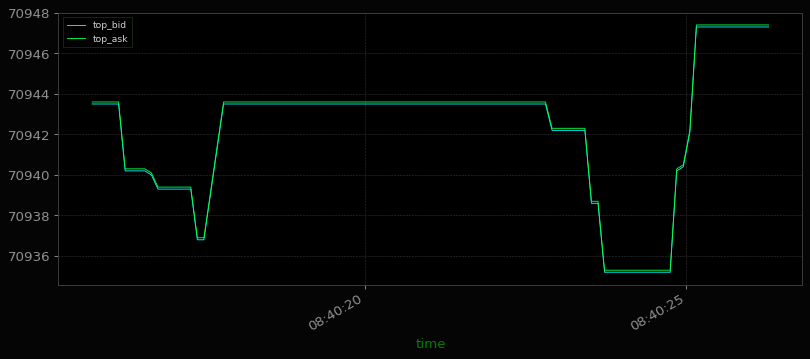

In [8]:
ob.pd()[["top_bid", "top_ask"]].iloc[-100:].plot();

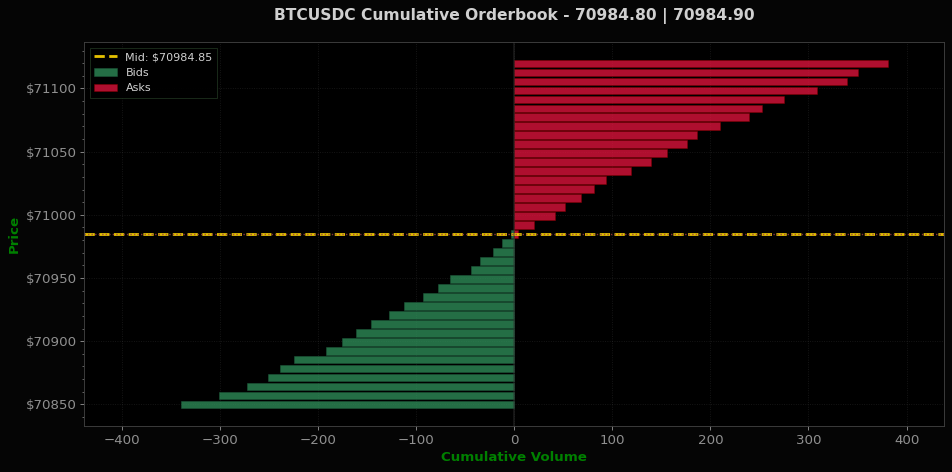

In [9]:
import matplotlib.pyplot as plt
from qubx.utils.charting.orderbook import plot_orderbook, plot_orderbook_depth, plot_orderbook_comparison

# Plot regular orderbook
# fig1, ax1 = plot_orderbook(ob, cumulative=False, max_levels=15,
#                           title=f"BTCUSDC Orderbook - {ob.top_bid:.2f} | {ob.top_ask:.2f}")
# plt.show()

# Plot cumulative orderbook
fig2, ax2 = plot_orderbook(
    ob[0],
    cumulative=True,
    max_levels=20,
    title=f"BTCUSDC Cumulative Orderbook - {ob[0].top_bid:.2f} | {ob[0].top_ask:.2f}",
    figsize=(12, 6),
)
plt.show()

# Plot depth chart
# fig3, ax3 = plot_orderbook_depth(ob, max_levels=15,
#                                 title=f"BTCUSDC Depth Chart - {ob.top_bid:.2f} | {ob.top_ask:.2f}")
# plt.show()

## 4.0 Orderbook Time Evolution Comparison

Let's compare how the orderbook has evolved over the last 10 snapshots.

In [10]:
obs = ctx.get_cached_market_data(instrument, DataType.ORDERBOOK)[:50]
len(obs)

50

Comparing 5 orderbook snapshots
Actual timestamps: ['08:40:43.641', '08:40:42.621', '08:40:41.393', '08:40:40.271', '08:40:38.535']
Labels: ['Now', 'T-1s', 'T-2s', 'T-3s', 'T-5s']


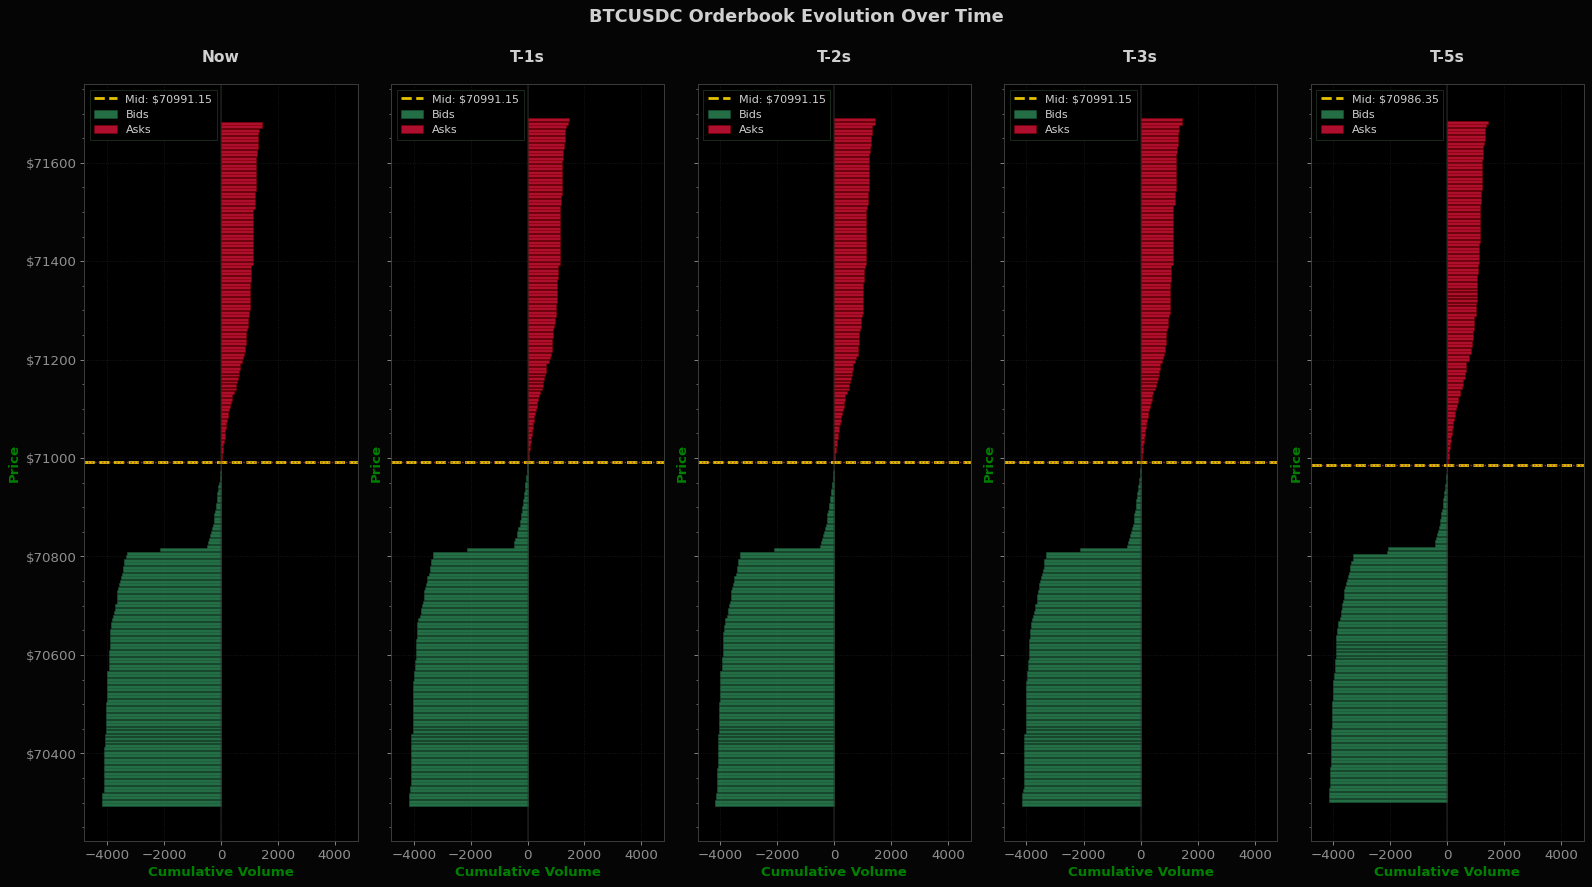

In [11]:
# Compare the evolution of orderbooks over time
# Let's take every 10th orderbook to avoid overcrowding (10 total)
comparison_obs = obs[::10]  # Take every 10th orderbook

# Create proper time labels using actual timestamps
timestamps = [pd.Timestamp(ob.time) for ob in comparison_obs]
current_time = pd.Timestamp(obs[0].time)
labels = []

for ts in timestamps:
    seconds_ago = int((current_time - ts).total_seconds())
    if seconds_ago == 0:
        labels.append("Now")
    elif seconds_ago < 60:
        labels.append(f"T-{seconds_ago}s")
    else:
        minutes_ago = seconds_ago // 60
        labels.append(f"T-{minutes_ago}m{seconds_ago % 60}s")

print(f"Comparing {len(comparison_obs)} orderbook snapshots")
print("Actual timestamps:", [ts.strftime("%H:%M:%S.%f")[:-3] for ts in timestamps])
print("Labels:", labels)

# Create comparison plot
fig, axes = plot_orderbook_comparison(comparison_obs, labels=labels, cumulative=True, figsize=(20, 12))
plt.suptitle("BTCUSDC Orderbook Evolution Over Time", fontsize=16, fontweight="bold", y=0.95)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

In [12]:
ctx.stop()